In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Ejercicio 2

saved


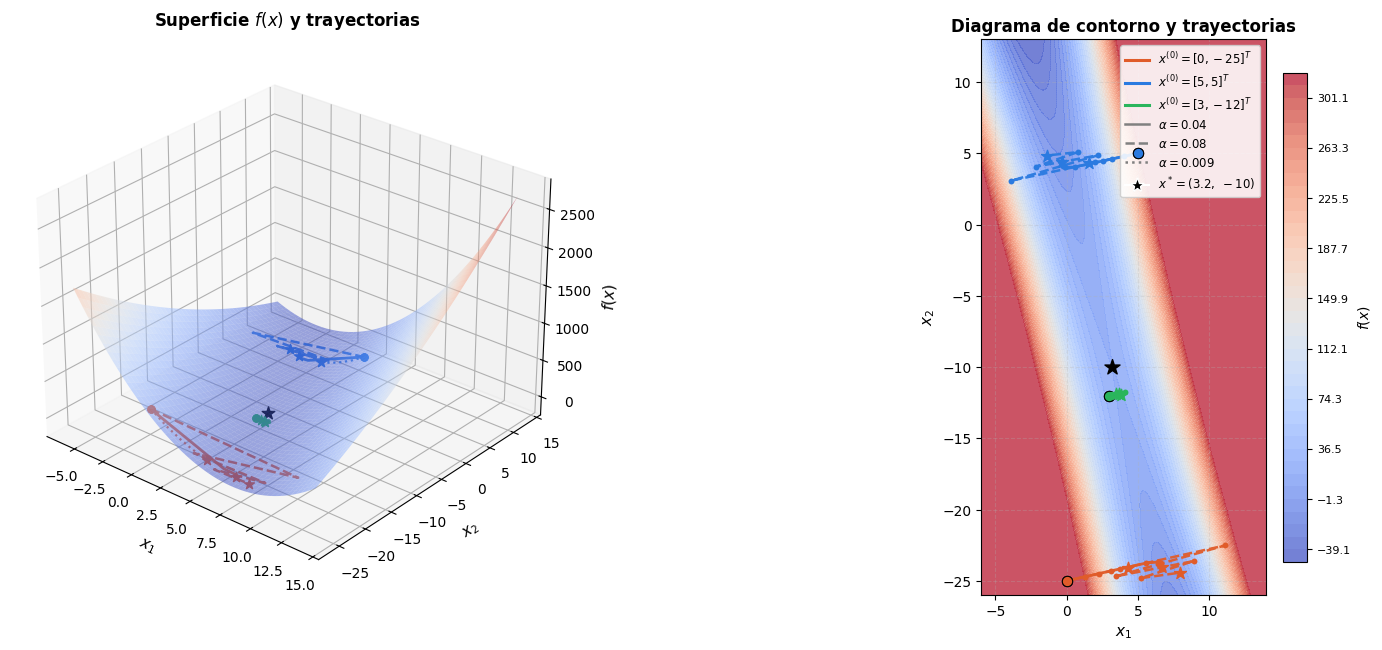

In [10]:
Q = np.array([[20,5],[5,1]], dtype=float)
c = np.array([14,6], dtype=float)
 
def f_grid(X1, X2):
    return (0.5*(20*X1**2 + 10*X1*X2 + X2**2) - 14*X1 - 6*X2 + 10)
 
def f(x): return 0.5*x@Q@x - c@x + 10
 
def grad(x): return Q@x - c
 
def iterate(x0, alpha, n=5):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    for _ in range(n):
        x = x - alpha*grad(x)
        path.append(x.copy())
    return np.array(path)
 
alphas     = [0.04, 0.08, 0.009]
ics        = [[0,-25], [5,5], [3,-12]]
colors_ic  = ['#e05c2a', '#2a7ae0', '#2ab55c']
ls_alpha   = ['-', '--', ':']
lw_alpha   = [2.0, 1.8, 1.6]
alpha_labels = [r'$\alpha=0.04$', r'$\alpha=0.08$', r'$\alpha=0.009$']
ic_labels    = [r'$x^{(0)}=[0,-25]^T$', r'$x^{(0)}=[5,5]^T$', r'$x^{(0)}=[3,-12]^T$']
x_star = np.array([3.2, -10.0])
 
x1g = np.linspace(-6, 14, 300)
x2g = np.linspace(-26, 13, 300)
X1, X2 = np.meshgrid(x1g, x2g)
Z = f_grid(X1, X2)
 
fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor('white')
 
# ── 3D ──────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(1, 2, 1, projection='3d')
ax3.plot_surface(X1, X2, Z, cmap='coolwarm', alpha=0.50,
                 linewidth=0, antialiased=True)
 
for ai, alpha in enumerate(alphas):
    for ci, ic in enumerate(ics):
        path = iterate(ic, alpha)
        fv   = np.array([f(p) for p in path])
        ax3.plot(path[:,0], path[:,1], fv,
                 color=colors_ic[ci], linestyle=ls_alpha[ai],
                 linewidth=lw_alpha[ai], alpha=0.9, zorder=5)
        ax3.scatter(path[0,0],  path[0,1],  fv[0],
                    color=colors_ic[ci], s=25, zorder=6)
        ax3.scatter(path[-1,0], path[-1,1], fv[-1],
                    color=colors_ic[ci], marker='*', s=55, zorder=6)
 
ax3.scatter(*x_star, f(x_star), color='black', s=90, marker='*', zorder=10)
ax3.set_xlabel(r'$x_1$', fontsize=11, labelpad=6)
ax3.set_ylabel(r'$x_2$', fontsize=11, labelpad=6)
ax3.set_zlabel(r'$f(x)$', fontsize=11, labelpad=6)
ax3.set_title(r'Superficie $f(x)$ y trayectorias', fontsize=12, fontweight='bold', pad=10)
ax3.view_init(elev=28, azim=-50)
 
# ── Contour ──────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)
Zc = np.clip(Z, Z.min(), 320)
levels = np.linspace(Zc.min(), 320, 40)
cp = ax2.contourf(X1, X2, Zc, levels=levels, cmap='coolwarm', alpha=0.72)
ax2.contour(X1, X2, Zc, levels=levels, colors='white', linewidths=0.25, alpha=0.35)
cb = fig.colorbar(cp, ax=ax2, label=r'$f(x)$', shrink=0.88, pad=0.02)
cb.ax.tick_params(labelsize=8)
 
legend_handles = []
for ai, alpha in enumerate(alphas):
    for ci, ic in enumerate(ics):
        path = iterate(ic, alpha)
        ax2.plot(path[:,0], path[:,1],
                 color=colors_ic[ci], linestyle=ls_alpha[ai],
                 linewidth=lw_alpha[ai], alpha=0.95, zorder=4)
        ax2.scatter(path[:,0], path[:,1],
                    color=colors_ic[ci], s=18, zorder=5, linewidths=0)
        ax2.scatter(path[0,0], path[0,1],
                    color=colors_ic[ci], s=55, zorder=6,
                    edgecolors='k', linewidths=0.7)
        ax2.scatter(path[-1,0], path[-1,1],
                    color=colors_ic[ci], marker='*', s=80, zorder=6)
    legend_handles.append(
        plt.Line2D([0],[0], color='gray', linestyle=ls_alpha[ai],
                   linewidth=1.8, label=alpha_labels[ai]))
 
for ci in range(3):
    legend_handles.insert(ci, plt.Line2D([0],[0], color=colors_ic[ci],
                                          linewidth=2.2, label=ic_labels[ci]))
 
ax2.scatter(*x_star, color='black', s=130, marker='*', zorder=10)
legend_handles.append(plt.Line2D([0],[0], marker='*', color='w',
                                  markerfacecolor='black', markersize=11,
                                  label=r'$x^*=(3.2,\ -10)$'))
 
ax2.set_xlabel(r'$x_1$', fontsize=11)
ax2.set_ylabel(r'$x_2$', fontsize=11)
ax2.set_title('Diagrama de contorno y trayectorias', fontsize=12, fontweight='bold')
ax2.legend(handles=legend_handles, fontsize=8.5, loc='upper right', framealpha=0.88)
ax2.set_xlim(-6, 14)
ax2.set_ylim(-26, 13)
ax2.grid(True, linestyle='--', alpha=0.28)
ax2.set_aspect('equal')
 
plt.tight_layout(pad=2.5)
plt.savefig('./gradient_plot.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print("saved")

## Ejercicio 3

In [ ]:
Q=np.array([[3,1],[1,2]], dtype=float)
b=np.array([2,1], dtype=float)

def f(x): return 0.5*x@Q@x - b@x

def grad(x): return Q@x - b

#Solucion analitica (referencia)
x_ref = np.linalg.solve(Q, b)

def gradient_descent(x0, alpha=0.1, tol=1e-6, max_iter=1000):
    x=x0.copy()
    history = []

    for k in range(max_iter):
        g = grad(x)
        grad_norm = np.linalg.norm(g)
        history.append({"k": k, "x": x.copy(), "f(x)": f(x),"grad": g.copy() ,"||grad||": grad_norm})

        if grad_norm < tol:
            print(f"Convergencia alcanzada en iteración {k} con ||grad||={grad_norm:.2e}")
            break

        x = x - alpha * g

    return x, history

x0    = np.array([0.0, 0.0])
alpha = 0.1
tol   = 1e-6

x_opt, history = gradient_descent(x0, alpha, tol)
print()
print(f"Solución encontrada : x = [{x_opt[0]:.6f}, {x_opt[1]:.6f}]")
print(f"Solución exacta     : x* = [{x_ref[0]:.6f}, {x_ref[1]:.6f}]")
print(f"Error               : ‖x - x*‖ = {np.linalg.norm(x_opt - x_ref):.2e}")
print(f"Total iteraciones   : {len(history) - 1}")

Convergencia alcanzada en iteración 83 con ||grad||=8.74e-07

Solución encontrada : x = [0.600000, 0.200001]
Solución exacta     : x* = [0.600000, 0.200000]
Error               : ‖x - x*‖ = 6.33e-07
Total iteraciones   : 83


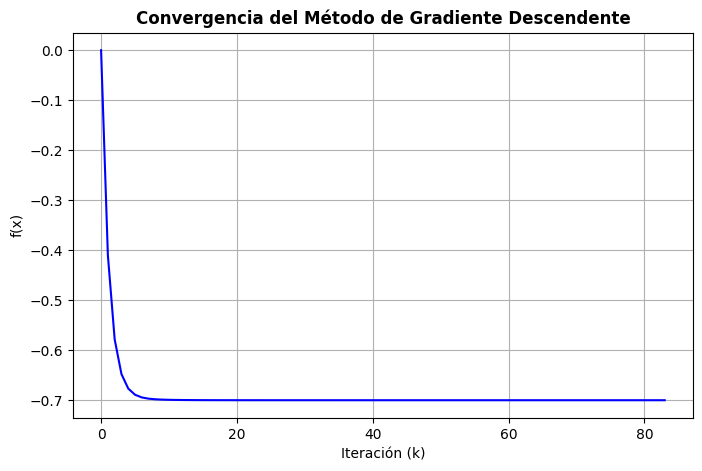

saved


In [19]:
#Grafica de convergencia
plt.figure(figsize=(8, 5))
plt.plot([h["k"] for h in history], [h["f(x)"] for h in history], linestyle='-', color='blue')
plt.title("Convergencia del Método de Gradiente Descendente", fontsize=12, fontweight='bold')
plt.xlabel("Iteración (k)", fontsize=10)
plt.ylabel("f(x)", fontsize=10)
plt.grid(True)
plt.savefig('./convergencia_gradient.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("saved")